# The second derivative of a smoothed image

`skimage.feature.hessian_matrix` computes second derivatives of an image at a
chosen scale. Four filters depend on it — `frangi`, `sato`, `meijering` and
`hessian` — and it has been through three implementations in as many years.

This is a review of how it works, why it was built the way it was, and what a
better version would look like. It builds up from the problem rather than from
the code, and every claim is measured against a standard fixed before any method
is judged.

`on_hessian.md` is the diagnostic companion: it goes further into each defect
and carries the candidate fixes in full. This document is the argument.

Coordinates are in array order throughout: the first index runs down the
picture, the second runs right.

In [1]:
import numpy as np
import pandas as pd
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from IPython.display import Markdown, display
from scipy.signal import resample


def show_table(df, **kwargs):
    """Render a DataFrame as a Markdown table in the notebook output."""
    display(Markdown(df.to_markdown(index=False, **kwargs)))

In [2]:
import skimage as ski
from skimage.feature import hessian_matrix
from skimage.filters import frangi, sato, meijering, hessian

In [3]:
# Slots 1 to 3 of the reference categorical palette, validated all-pairs.
C_ONE, C_TWO, C_THREE = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dedcd5"
SEQ = LinearSegmentedColormap.from_list("seq", ["#f7f7f4", C_ONE])
DIV = LinearSegmentedColormap.from_list("div", [C_ONE, "#f2f1ec", C_TWO])

plt.rcParams.update(
    {"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9,
     "axes.titlecolor": MUTED, "figure.facecolor": "white"}
)


def show(ax, data, title=None, diverging=False):
    if diverging:
        limit = np.abs(data).max() or 1.0
        image = ax.imshow(data, cmap=DIV, norm=TwoSlopeNorm(0, -limit, limit))
    else:
        image = ax.imshow(data, cmap=SEQ)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(title)
    return image


def recede(ax, title=None):
    ax.tick_params(labelsize=8, colors=MUTED)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRID)
    if title:
        ax.set_title(title)
    return ax

## 1. The problem

An image is a grid of numbers. A derivative is a limit over distances that go to
zero. The grid has no values between its samples, so the derivative of an image
is not defined until we say what we mean by it.

Differencing neighbouring pixels is the obvious answer and a bad one: it
amplifies noise without limit, and the answer changes if the same scene is
photographed at a different resolution. The standard remedy is to **fix a
scale**. Convolve with a Gaussian of width `sigma`, which is smooth and
differentiable, and differentiate that instead. The scale is then part of the
question rather than an accident of the sensor.

For second derivatives this gives the **Hessian at scale sigma**: for a 2-D
image, three distinct entries, because mixed partials are equal.

```
    H = | Hii  Hij |          Hij = d2/di dj  ( G_sigma * f )
        | Hij  Hjj |
```

Its eigenvalues describe local curvature. At each pixel the Hessian is a
symmetric 2×2 matrix, so it has two real eigenvalues `λ` and two orthogonal
eigenvectors. Each eigenvalue is the second directional derivative of the
smoothed image along its eigenvector: how sharply the intensity bends when you
step in that direction. The eigenvectors are the principal-curvature axes —
the directions of strongest and weakest bend.

Sign and magnitude both matter. For a bright structure on a dark background,
curvature toward the structure is **negative** (the intensity has a local
maximum along that axis). Two large negative eigenvalues mean the surface bends
down in every direction — a blob. One large negative eigenvalue and one near
zero mean it bends across a line but is flat along it — a ridge. That is the
basis of ridge detection, which is what `frangi`, `sato` and `meijering` do.

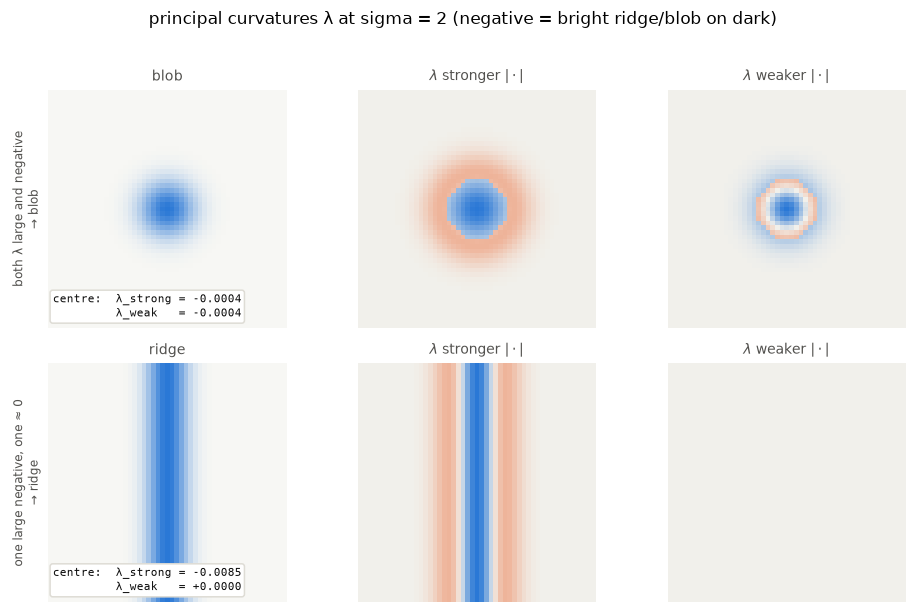

In [4]:
from skimage.feature import hessian_matrix_eigvals

BLOB_N, BLOB_S = 121, 4.0
centre = BLOB_N // 2
bi, bj = np.indices((BLOB_N, BLOB_N), dtype=float)
radius2 = (bi - centre) ** 2 + (bj - centre) ** 2
blob = np.exp(-radius2 / (2 * BLOB_S**2)) / (2 * np.pi * BLOB_S**2)

# A vertical bright ridge: curved across columns, flat along rows.
RIDGE_W = 3.0
ridge = (np.exp(-((bj - centre) ** 2) / (2 * RIDGE_W**2))
         / (np.sqrt(2 * np.pi) * RIDGE_W))

crop = slice(35, -35)


def eig_pair(image, sigma=2.0):
    """Stronger and weaker principal curvatures, by |λ|.

    `hessian_matrix_eigvals` returns eigenvalues in ascending algebraic order
    (most negative first). Here we re-sort by magnitude so the panels compare
    curvature *strength*, and the sign on each panel still shows bright vs dark.
    """
    elems = hessian_matrix(image, sigma=sigma, mode="nearest",
                           use_gaussian_derivatives=True)
    eigs = hessian_matrix_eigvals(elems)
    order = np.argsort(np.abs(eigs), axis=0)
    by_mag = np.take_along_axis(eigs, order, axis=0)
    return by_mag[1], by_mag[0]                  # λ_strong, λ_weak


fig, axes = plt.subplots(2, 3, figsize=(9.0, 5.4))
for row, (image, label) in enumerate(((blob, "blob"), (ridge, "ridge"))):
    strong, weak = eig_pair(image)
    show(axes[row, 0], image[crop, crop], label)
    show(axes[row, 1], strong[crop, crop], r"$\lambda$ stronger $|\cdot|$",
         diverging=True)
    show(axes[row, 2], weak[crop, crop], r"$\lambda$ weaker $|\cdot|$",
         diverging=True)
    # Centre values: concrete numbers for the pattern the eye should see.
    axes[row, 0].text(
        0.02, 0.05,
        f"centre:  λ_strong = {strong[centre, centre]:+.4f}\n"
        f"         λ_weak   = {weak[centre, centre]:+.4f}",
        transform=axes[row, 0].transAxes, fontsize=7, color=INK,
        family="monospace",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=GRID),
    )

axes[0, 0].set_ylabel("both λ large and negative\n→ blob",
                      fontsize=8, color=MUTED)
axes[1, 0].set_ylabel("one large negative, one ≈ 0\n→ ridge",
                      fontsize=8, color=MUTED)
fig.suptitle("principal curvatures λ at sigma = 2 "
             "(negative = bright ridge/blob on dark)",
             y=1.02)
fig.tight_layout()

On the blob the two centre values are equal and negative: isotropic downward
bend. On the ridge the strong eigenvalue is negative (bend across the line) and
the weak one is ~0 (no bend along it). Blue in the maps is that negative
curvature; the weak panel for the ridge is nearly blank because there is almost
nothing to show.

The three Hessian entries themselves are the second derivatives that those
eigenvalues are built from:

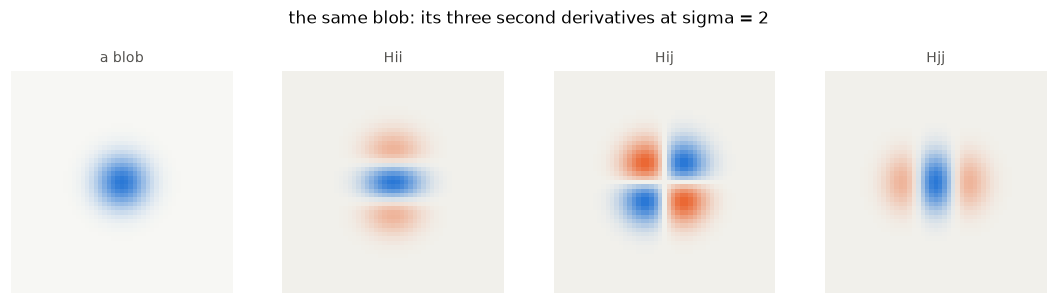

In [5]:
entries = hessian_matrix(blob, sigma=2.0, mode="nearest",
                         use_gaussian_derivatives=True)

fig, axes = plt.subplots(1, 4, figsize=(10.0, 2.6))
show(axes[0], blob[crop, crop], "a blob")
for ax, name, entry in zip(axes[1:], ("Hii", "Hij", "Hjj"), entries):
    show(ax, entry[crop, crop], name, diverging=True)
fig.suptitle("the same blob: its three second derivatives at sigma = 2", y=1.04)
fig.tight_layout()

So the quantity we are after is fixed and unambiguous: the second derivative of
the image *after* smoothing by a Gaussian of width `sigma`. The rest of this
document is about how to compute that quantity on a discrete grid, and how to
tell whether a given method has computed it correctly.

## 2. Two ways to compute it

Convolution and differentiation commute. For a Gaussian `G` and an image `f`:

```
    d/dx ( G * f )  ==  ( dG/dx ) * f
```

Either side is a route to the same continuous quantity, and the two sides
suggest two different programs.

**Route A — smooth, then difference.** Take the left-hand side literally. Blur
the image, then apply a numerical derivative to the blurred result. The
derivative can be the simplest central difference; the blurring has already done
the work of making that safe.

**Route B — differentiate the Gaussian.** Take the right-hand side. Build a
kernel that is already the second derivative of a Gaussian and convolve once.
No differencing step exists to be inaccurate.

In [6]:
def route_a(image, sigma, mode="nearest"):
    """Smooth, then difference: the left-hand side, literally."""
    smoothed = ndi.gaussian_filter(image, sigma, mode=mode)
    d_i, d_j = np.gradient(smoothed)
    d_ii, d_ij = np.gradient(d_i)
    _, d_jj = np.gradient(d_j)
    return [d_ii, d_ij, d_jj]


def route_b(image, sigma, mode="nearest"):
    """Convolve once with a derivative-of-Gaussian kernel: the right-hand side."""
    return [ndi.gaussian_filter(image, sigma, order=order, mode=mode)
            for order in ([2, 0], [1, 1], [0, 2])]

Both are a few lines, both return something plausible, and at a comfortable
scale they agree.

In [7]:
a, b = route_a(blob, 2.0), route_b(blob, 2.0)
scale = max(np.abs(e).max() for e in b)
worst = max(np.abs(x - y).max() for x, y in zip(a, b))
print(f"route A against route B at sigma = 2: worst difference "
      f"{worst / scale:.2%} of the peak response")

route A against route B at sigma = 2: worst difference 4.85% of the peak response


A few per cent apart. Which of them is closer to the answer? Nothing so far can
say — the two routes only disagree with each other. That needs a third thing.

## 3. A standard to judge them by

Two approximations that differ tell you only that at least one is wrong. To say
which, we need a reference computed a third way, decided before any method is
put on trial.

There are two available, and they check each other.

### 3.1 A closed form, for images made of Gaussians

A Gaussian smoothed by a Gaussian is another Gaussian, with
`t**2 = s**2 + sigma**2`. So for a test image built from Gaussians, the smoothed
Hessian is known exactly, in closed form, with no discretisation anywhere.

In [8]:
def analytic_hessian(sigma):
    """The exact Hessian of the blob after smoothing at `sigma`."""
    t2 = BLOB_S**2 + sigma**2
    g = np.exp(-radius2 / (2 * t2)) / (2 * np.pi * t2)
    di, dj = bi - centre, bj - centre
    return [g * (di**2 / t2**2 - 1 / t2),
            g * (di * dj / t2**2),
            g * (dj**2 / t2**2 - 1 / t2)]


INTERIOR = slice(35, -35)


def error_against(computed, truth):
    """Worst disagreement over the three entries, away from the border."""
    scale = max(np.abs(e).max() for e in truth)
    return max(np.abs(a[INTERIOR, INTERIOR] - b[INTERIOR, INTERIOR]).max()
               for a, b in zip(computed, truth)) / scale

This is exact but narrow: it holds only for images we construct, and a method
could in principle do well on a smooth blob and badly on a photograph.

### 3.2 Supersampling, for any image

The second standard removes that limitation and costs a great deal.

Treat the image as samples of a continuous function — which is the assumption
that makes "the derivative of an image" mean anything at all. Reconstruct that
function on a grid `k` times finer, where the sampling is `k` times denser and
so the discretisation error is `k`-fold smaller. Do the differentiation there,
at scale `k * sigma` in fine-grid units. Then return to the original grid.

The reconstruction is band-limited resampling, which is the interpolation
consistent with that same assumption. A second derivative with respect to coarse
coordinates is `k**2` times the derivative with respect to fine ones, which is
the only scaling involved.

In [9]:
def upsample(image, factor):
    """Band-limited resampling onto a `factor` times finer grid."""
    finer = resample(image, image.shape[0] * factor, axis=0)
    return resample(finer, image.shape[1] * factor, axis=1)


def gold_hessian(image, sigma, factor=4, mode="nearest"):
    """The reference: differentiate where the sampling error is negligible.

    Pad once, resample finer, take the derivative at `factor * sigma`, decimate,
    crop. Costs `factor**2` in memory and time, which is why it is a yardstick
    and not an implementation.

    `mode` must match the method under test. A reference that extends the image
    by a different rule measures that difference and calls it an error.
    """
    # `ndimage` and `numpy.pad` spell the same rules differently.
    pad_mode = {"nearest": "edge", "reflect": "symmetric", "mirror": "reflect",
                "wrap": "wrap", "constant": "constant"}[mode]
    pad = int(np.ceil(8 * sigma)) + 2
    fine = upsample(np.pad(image, pad, mode=pad_mode), factor)
    elems = [ndi.gaussian_filter(fine, factor * sigma, order=order, mode=mode,
                                 truncate=8)
             for order in ([2, 0], [1, 1], [0, 2])]
    coarse = [(e[::factor, ::factor] * factor**2) for e in elems]
    return [e[pad:-pad, pad:-pad] for e in coarse]

Two details in that function are not decoration. The image is padded **once**,
before anything else happens, so the boundary rule is applied a single time —
any reference that extends the image more than once is measuring its own
artefacts. And the padding clears the kernel, so the crop never sees an edge.
The fine-grid derivatives still use SciPy's uncorrected `order=2` kernels; at
`factor * sigma` those kernels are already well sampled (section 5), so the
yardstick is not carrying the small-sigma leak it is used to judge.

### 3.3 The two standards agree

The supersampled reference is only worth having if it converges to the answer we
already know. On the blob, where the closed form applies, it does.

In [10]:
factors = (1, 2, 4, 8)
rows = []
for sigma in (0.3, 0.4, 0.5, 0.7, 1.0, 2.0):
    row = {"sigma": sigma}
    for k in factors:
        err = error_against(gold_hessian(blob, sigma, factor=k),
                            analytic_hessian(sigma))
        row[f"k = {k}"] = f"{err:.3%}"
    rows.append(row)
show_table(pd.DataFrame(rows))

|   sigma | k = 1      | k = 2    | k = 4   | k = 8   |
|--------:|:-----------|:---------|:--------|:--------|
|     0.3 | 16384.702% | 428.134% | 0.000%  | 0.000%  |
|     0.4 | 5069.735%  | 1.850%   | 0.000%  | 0.000%  |
|     0.5 | 952.745%   | 0.002%   | 0.000%  | 0.000%  |
|     0.7 | 10.303%    | 0.000%   | 0.000%  | 0.000%  |
|     1   | 0.001%     | 0.000%   | 0.000%  | 0.000%  |
|     2   | 0.000%     | 0.000%   | 0.000%  | 0.000%  |

At `k = 4` the reference reproduces the closed form to the printed precision at
every scale, and refining further changes nothing. So `k = 4` is enough, and the
reference is trustworthy on images with no closed form.

The `k = 1` column is worth a second look, because it is not a reference at all:
it is route B computed directly on the original grid, with no refinement. At
`sigma = 0.3` it is wrong by a factor of a hundred and sixty. That is the first
sign of the problem section 5 is about, and it appears here as a control rather
than as a claim.

From here on, **the standard** means `gold_hessian` at `k = 4`, and every
comparison is against it.

## 4. Why the library moved from differences to Gaussian derivatives

With a standard in hand the two routes of section 2 can be judged rather than
compared.

In [11]:
SCALES = (0.4, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0)

rows = []
for sigma in SCALES:
    truth = gold_hessian(blob, sigma)
    rows.append({
        "sigma": sigma,
        "route A, differences": f"{error_against(route_a(blob, sigma), truth):.2%}",
        "route B, Gaussian": f"{error_against(route_b(blob, sigma), truth):.2%}",
    })
show_table(pd.DataFrame(rows))

|   sigma | route A, differences   | route B, Gaussian   |
|--------:|:-----------------------|:--------------------|
|     0.4 | 5.02%                  | 5069.74%            |
|     0.5 | 5.49%                  | 952.75%             |
|     0.7 | 5.81%                  | 10.31%              |
|     1   | 5.66%                  | 0.07%               |
|     1.5 | 5.28%                  | 0.09%               |
|     2   | 4.83%                  | 0.10%               |
|     3   | 3.89%                  | 0.09%               |
|     5   | 2.39%                  | 0.09%               |

Route A sits on a floor of a few per cent that no amount of smoothing removes.
Route B is a tenth of a per cent out above `sigma = 1` — fifty times better —
and falls apart below it, by four orders of magnitude.

The floor has a clean explanation. `np.gradient` uses the central difference
`(f[n+1] - f[n-1]) / 2`, whose frequency response is `i sin(w)` where the true
derivative's is `i w`. Applying it twice gives `-sin(w)**2` against `-w**2`. The
ratio `sin(w)**2 / w**2` is 1 only at `w = 0` and falls away everywhere else, so
the operator under-reports curvature at every frequency the image actually
contains.

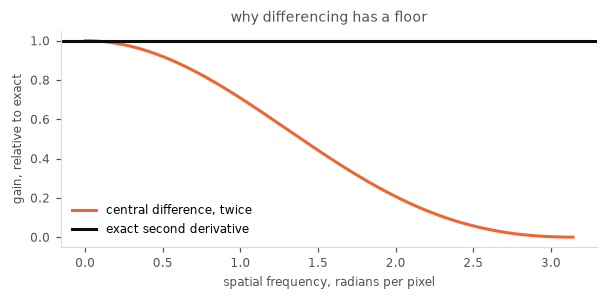

In [12]:
w = np.linspace(1e-6, np.pi, 400)

fig, ax = plt.subplots(figsize=(5.6, 2.8))
ax.plot(w, np.sin(w) ** 2 / w**2, color=C_TWO, lw=2,
        label="central difference, twice")
ax.axhline(1.0, color=INK, lw=2, label="exact second derivative")
ax.set_xlabel("spatial frequency, radians per pixel", fontsize=8, color=MUTED)
ax.set_ylabel("gain, relative to exact", fontsize=8, color=MUTED)
recede(ax, "why differencing has a floor")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

Smoothing more does not help, because smoothing changes what the image contains,
not what the operator does to it: the shortfall at each frequency is fixed. That
is why route A's column is flat.

This is the case for the switch, and `hessian_matrix` has a
`use_gaussian_derivatives` argument that makes it, with a `FutureWarning`
announcing that route B will become the default. Above `sigma = 1` the argument
is unanswerable — route B is exact where route A is wrong by 4%.

Below `sigma = 1` it reverses, and badly. That is the next section.

## 5. The two-pass solution, and why it was chosen

The naive form of route B is to ask SciPy for a second-order derivative
directly, `order=[2, 0]`. Doing so fails at small `sigma` in a way that is easy
to see and hard to argue with: the operator responds to an image with no
structure at all. A second derivative must return 0 on a constant and 1 on
`r**2 / 2`:

In [13]:
flat = np.ones((40, 40))
ramp = np.repeat((np.arange(400.0)[:, None] - 200) ** 2 / 2, 8, axis=1)

rows = []
for sigma in (0.5, 0.7, 1.0, 1.5):
    on_flat = ndi.gaussian_filter(flat, sigma, order=[2, 0], mode="nearest")[20, 20]
    on_ramp = ndi.gaussian_filter(ramp, sigma, order=[2, 0], mode="nearest")[200, 4]
    rows.append({"sigma": sigma, "constant": on_flat, "quadratic": on_ramp})
show_table(pd.DataFrame(rows), floatfmt=".4f")

|   sigma |   constant |   quadratic |
|--------:|-----------:|------------:|
|  0.5000 |    -0.5598 |      1.3407 |
|  0.7000 |    -0.0050 |      1.0174 |
|  1.0000 |    -0.0001 |      0.9991 |
|  1.5000 |    -0.0001 |      0.9976 |

At `sigma = 0.5` a flat field reads as curvature of `-0.56`. The cause is
sampling: the kernel is built by evaluating the continuous second derivative of
a Gaussian on the integer grid, and at half a pixel wide that formula swings
through its whole range between one sample and the next. The positive flanks no
longer cancel the negative well, so the coefficients do not sum to zero, and a
kernel that does not sum to zero responds to constants.

In one dimension the failure is two moment conditions that any discrete second
derivative must meet:

```
    sum(k)             ==  0        no response to a constant
    sum(k * x**2) / 2  ==  1        exact on f = x**2 / 2
```

At small `sigma` the sampled G'' breaks both.

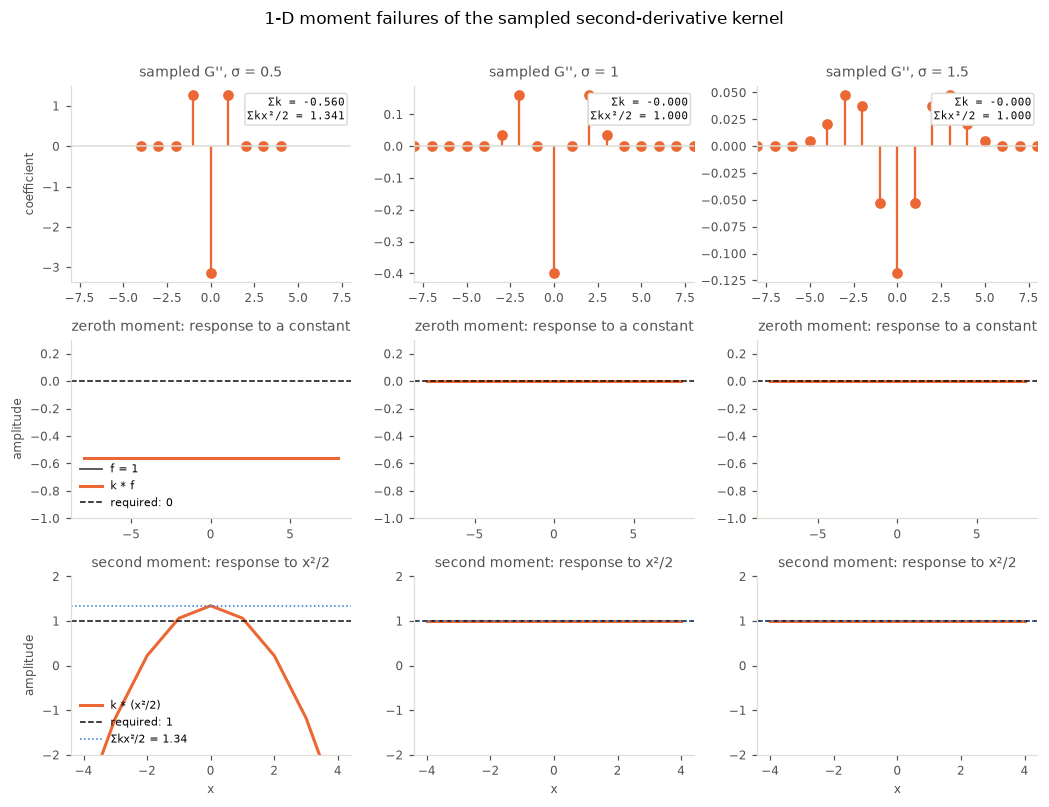

In [14]:
def sampled_g2(sigma, truncate=8):
    """1-D second derivative of a Gaussian, sampled on the integer grid."""
    reach = int(truncate * sigma + 0.5)
    x = np.arange(-reach, reach + 1, dtype=float)
    g = np.exp(-(x**2) / (2 * sigma**2))
    g /= g.sum()
    return x, g * ((x**2 - sigma**2) / sigma**4)


def apply_1d(signal, kernel):
    return ndi.correlate1d(signal, kernel, mode="nearest")


# Domain wide enough that edge effects sit outside the plotted window.
x = np.arange(-80, 81, dtype=float)
constant = np.ones_like(x)
quadratic = x**2 / 2
mid = 80
win_c = slice(mid - 8, mid + 9)               # |x| <= 8
win_q = slice(mid - 4, mid + 5)               # |x| <= 4; keeps the bow in view

fig, axes = plt.subplots(3, 3, figsize=(9.6, 7.2),
                         gridspec_kw={"height_ratios": [1.1, 1, 1]})
for col, sigma in enumerate((0.5, 1.0, 1.5)):
    kx, k = sampled_g2(sigma)
    m0, m2 = k.sum(), (k * kx**2).sum() / 2
    resp_c = apply_1d(constant, k)
    resp_q = apply_1d(quadratic, k)

    axes[0, col].stem(kx, k, linefmt=C_TWO, markerfmt="o", basefmt=" ")
    axes[0, col].axhline(0, color=GRID, lw=1)
    axes[0, col].set_xlim(-8, 8)
    recede(axes[0, col], f"sampled G'', σ = {sigma:g}")
    axes[0, col].text(
        0.98, 0.95,
        f"Σk = {m0:+.3f}\nΣkx²/2 = {m2:.3f}",
        transform=axes[0, col].transAxes, ha="right", va="top",
        fontsize=7, family="monospace", color=INK,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor=GRID),
    )

    axes[1, col].plot(x[win_c], constant[win_c], color=MUTED, lw=1.2,
                      label="f = 1")
    axes[1, col].plot(x[win_c], resp_c[win_c], color=C_TWO, lw=2,
                      label="k * f")
    axes[1, col].axhline(0, color=INK, lw=1, ls="--", label="required: 0")
    recede(axes[1, col], "zeroth moment: response to a constant")
    axes[1, col].set_ylim(-1.0, 0.3)

    # Near the origin the quadratic response should be the flat line 1.
    # A non-zero Σk mixes in a multiple of x²/2 and bows the curve.
    axes[2, col].plot(x[win_q], resp_q[win_q], color=C_TWO, lw=2,
                      label="k * (x²/2)")
    axes[2, col].axhline(1, color=INK, lw=1, ls="--", label="required: 1")
    axes[2, col].axhline(m2, color=C_ONE, lw=1, ls=":",
                         label=f"Σkx²/2 = {m2:.2f}")
    recede(axes[2, col], "second moment: response to x²/2")
    axes[2, col].set_ylim(-2.0, 2.0)
    axes[2, col].set_xlabel("x", fontsize=8, color=MUTED)

axes[1, 0].legend(frameon=False, fontsize=7, loc="lower left")
axes[2, 0].legend(frameon=False, fontsize=7, loc="lower left")
axes[0, 0].set_ylabel("coefficient", fontsize=8, color=MUTED)
axes[1, 0].set_ylabel("amplitude", fontsize=8, color=MUTED)
axes[2, 0].set_ylabel("amplitude", fontsize=8, color=MUTED)
fig.suptitle("1-D moment failures of the sampled second-derivative kernel",
             y=1.01)
fig.tight_layout()

At `sigma = 0.5` the kernel sums to −0.56, so a constant comes back as that
same number (middle row). The second moment is 1.34 instead of 1, and the
non-zero sum also folds a multiple of `x²/2` into the response, so the bottom
row bows instead of sitting on the dashed line at 1. By `sigma = 1.5` both
moments are already right to the printed precision. The 2-D picture is the same
zeroth-moment leak, drawn as an image:

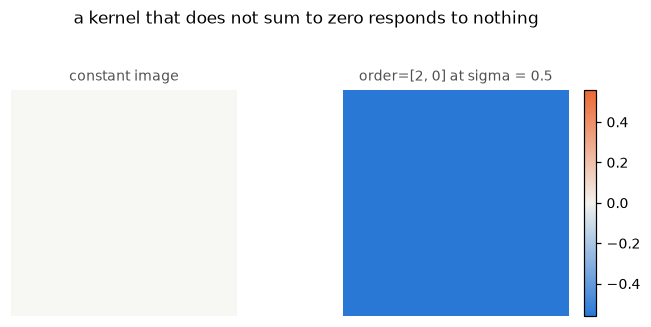

In [15]:
# The leak is not a scalar curiosity: it paints a non-zero field onto a blank.
flat_big = np.ones((64, 64))
naive_flat = ndi.gaussian_filter(flat_big, 0.5, order=[2, 0], mode="nearest")

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8))
show(axes[0], flat_big, "constant image")
im = show(axes[1], naive_flat, "order=[2, 0] at sigma = 0.5", diverging=True)
fig.colorbar(im, ax=axes[1], fraction=0.046)
fig.suptitle("a kernel that does not sum to zero responds to nothing", y=1.04)
fig.tight_layout()

This was reported in 2021 as
[*Are scipy second-order Gaussian derivatives correct?*](https://dsp.stackexchange.com/questions/78280/are-scipy-second-order-gaussian-derivatives-correct),
by someone who met it on an image that was constant down every column and got
`1e-5` where zero was the only right answer.

**The fix `scikit-image` adopted is in the same question.** Rather than ask for a
second derivative, ask for a first derivative twice. The source records the
decision:

```python
    # Apply two successive first order Gaussian derivative operations, as
    # detailed in:
    # https://dsp.stackexchange.com/questions/78280/are-scipy-second-order-gaussian-derivatives-correct
```

It works, and for a reason worth stating plainly: a **first**-derivative kernel
is odd, `k[-n] == -k[n]`, so its coefficients cancel in pairs and it sums to zero
by symmetry no matter how coarsely it is sampled. Composing two of them never
asks SciPy for the even kernel that leaks. Each pass uses `sigma / sqrt(2)`,
because two Gaussians of that width compose to one of width `sigma`.

In [16]:
def two_pass(image, sigma, mode="nearest"):
    """The shipped scheme: two first-order passes at sigma / sqrt(2)."""
    scaled = sigma / np.sqrt(2)
    kwargs = dict(mode=mode, truncate=8 if sigma > 1 else 100)
    grad_i = ndi.gaussian_filter(image, scaled, order=[1, 0], **kwargs)
    grad_j = ndi.gaussian_filter(image, scaled, order=[0, 1], **kwargs)
    return [ndi.gaussian_filter(grad_i, scaled, order=[1, 0], **kwargs),
            ndi.gaussian_filter(grad_i, scaled, order=[0, 1], **kwargs),
            ndi.gaussian_filter(grad_j, scaled, order=[0, 1], **kwargs)]


print("the same two tests, two-pass")
rows = []
for sigma in (0.5, 0.7, 1.0, 1.5):
    rows.append({
        "sigma": sigma,
        "constant": two_pass(flat, sigma)[0][20, 20],
        "quadratic": two_pass(ramp, sigma)[0][200, 4],
    })
show_table(pd.DataFrame(rows), floatfmt=".4f")

the same two tests, two-pass


|   sigma |   constant |   quadratic |
|--------:|-----------:|------------:|
|  0.5000 |     0.0000 |      0.0799 |
|  0.7000 |     0.0000 |      0.7205 |
|  1.0000 |     0.0000 |      0.9959 |
|  1.5000 |     0.0000 |      1.0000 |

The response to a constant is now exactly zero at every scale, which is what the
change was for. The quadratic column shows what it cost: at `sigma = 0.5` the
scheme reports 8% of the curvature that is there. The leak is gone and the gain
has collapsed in its place.

The same source carries one more decision, and it is worth quoting because its
reasoning is checkable:

```python
    # For small sigma, the SciPy Gaussian filter suffers from aliasing and edge
    # artifacts, given that the filter will approximate a sinc or sinc
    # derivative which only goes to 0 very slowly (order 1/n**2). Thus, we use
    # a much larger truncate value to reduce any edge artifacts.
    truncate = 8 if all(s > 1 for s in sigma) else 100
```

The diagnosis is right and the remedy does not follow from it. A sampled
Gaussian derivative decays like a Gaussian, not like a sinc, so the far taps a
wide window keeps are not small-but-helpful — they are zero, and the moments a
narrow window gets wrong a wide one gets wrong identically. (The shipped guard
applies to the *first*-order passes at `sigma / sqrt(2)`; the second-derivative
taps below make the same point more directly, because that is the kernel whose
leak the two-pass scheme was written to avoid.)

In [17]:
def taps(sigma, order, truncate):
    """The 1-D kernel `gaussian_filter` builds, from the explicit formula."""
    reach = int(truncate * sigma + 0.5)
    x = np.arange(-reach, reach + 1).astype(float)
    g = np.exp(-(x**2) / (2 * sigma**2))
    g /= g.sum()
    if order == 0:
        return x, g
    if order == 1:
        return x, g * (x / sigma**2)
    return x, g * ((x**2 - sigma**2) / sigma**4)


x_wide, k_wide = taps(0.5, 2, 100)
mid = k_wide.size // 2
peak = np.abs(k_wide).max()
show_table(pd.DataFrame([
    {"n": n,
     "|k[n]| / peak": abs(k_wide[mid + n]) / peak,
     "1/n**2": 1.0 / n**2}
    for n in (1, 2, 4, 8)
]), floatfmt=".1e")

x_narrow, k_narrow = taps(0.5, 2, 8)
show_table(pd.DataFrame([
    {"truncate": 8, "sum of taps": f"{k_narrow.sum():+.4f}"},
    {"truncate": 100, "sum of taps": f"{k_wide.sum():+.4f}"},
]))

|       n |   |k[n]| / peak |   1/n**2 |
|--------:|----------------:|---------:|
| 1.0e+00 |         4.1e-01 |  1.0e+00 |
| 2.0e+00 |         5.0e-03 |  2.5e-01 |
| 4.0e+00 |         8.0e-13 |  6.2e-02 |
| 8.0e+00 |         6.6e-54 |  1.6e-02 |

|   truncate |   sum of taps |
|-----------:|--------------:|
|          8 |       -0.5598 |
|        100 |       -0.5598 |

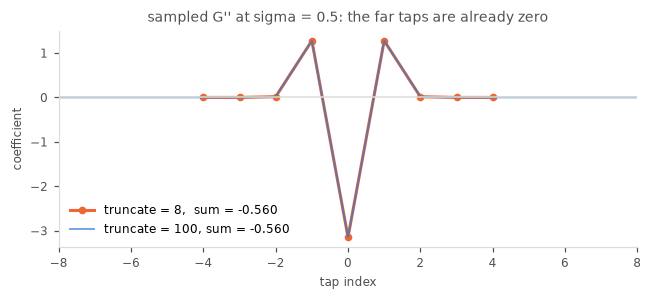

In [18]:
# Same support, same leak: widening the window does not restore sum(k) = 0.
fig, ax = plt.subplots(figsize=(6.0, 2.8))
ax.plot(x_narrow, k_narrow, color=C_TWO, lw=2, marker="o", ms=4,
        label=f"truncate = 8,  sum = {k_narrow.sum():+.3f}")
ax.plot(x_wide, k_wide, color=C_ONE, lw=1.2, alpha=0.7,
        label=f"truncate = 100, sum = {k_wide.sum():+.3f}")
ax.axhline(0, color=GRID, lw=1)
ax.set_xlim(-8, 8)
ax.set_xlabel("tap index", fontsize=8, color=MUTED)
ax.set_ylabel("coefficient", fontsize=8, color=MUTED)
recede(ax, "sampled G'' at sigma = 0.5: the far taps are already zero")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

Fifty-two orders of magnitude apart at `n = 8`, and the two sums are identical.
`truncate = 100` buys nothing and costs a great deal, because every reference
and every padded construction downstream has to clear a hundred-pixel radius
rather than eight. Section 7 removes the reason for it.

## 6. The two-pass solution against the standard

The scheme is what `hessian_matrix` ships today. Measured against the standard,
it is good in the interior above `sigma = 1`, and it has two faults that the
tests in section 5 could not see.

In [19]:
PHOTO = ski.util.img_as_float(ski.data.camera())[::2, ::2]


def border_and_interior(method, image, sigma, margin=20):
    """Worst disagreement with the standard, at the border and away from it."""
    truth = gold_hessian(image, sigma)
    got = method(image, sigma)
    scale = max(np.abs(e).max() for e in truth)
    inner = (slice(margin, -margin),) * 2
    return (max(np.abs(a - b).max() for a, b in zip(got, truth)) / scale,
            max(np.abs(a[inner] - b[inner]).max() for a, b in zip(got, truth)) / scale)


rows = []
for sigma in (0.5, 1.0, 1.5, 3.0):
    whole, inner = border_and_interior(two_pass, PHOTO, sigma)
    rows.append({
        "sigma": sigma,
        "worst anywhere": f"{whole:.1%}",
        "interior only": f"{inner:.1%}",
    })
show_table(pd.DataFrame(rows))

|   sigma | worst anywhere   | interior only   |
|--------:|:-----------------|:----------------|
|     0.5 | 97.5%            | 97.5%           |
|     1   | 19.2%            | 10.3%           |
|     1.5 | 18.9%            | 0.0%            |
|     3   | 19.2%            | 0.0%            |

**The first fault is at the border**, and it does not shrink with `sigma`. From
`sigma = 1.5` upwards the interior is exact and the border is still about a
fifth of the peak wrong — roughly 19% at `sigma = 1.5` and `3`, of the same
order at larger scales.

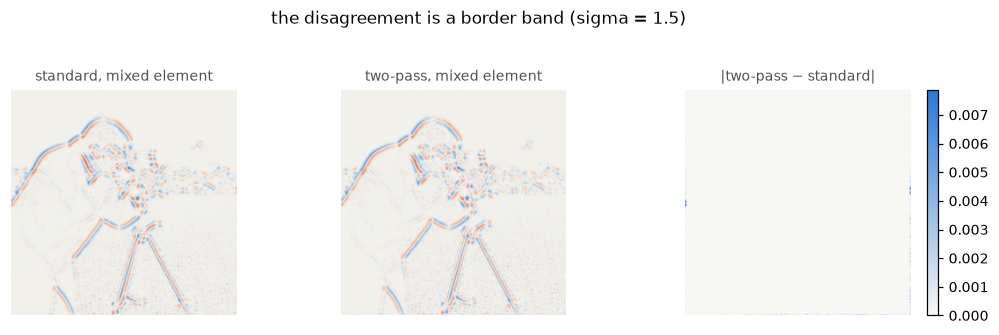

In [20]:
sigma = 1.5
truth = gold_hessian(PHOTO, sigma)
gap = np.abs(two_pass(PHOTO, sigma)[1] - truth[1])

fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.8))
show(axes[0], truth[1], "standard, mixed element", diverging=True)
show(axes[1], two_pass(PHOTO, sigma)[1], "two-pass, mixed element", diverging=True)
im = show(axes[2], gap, "|two-pass − standard|")
fig.colorbar(im, ax=axes[2], fraction=0.046)
fig.suptitle(f"the disagreement is a border band (sigma = {sigma})", y=1.04)
fig.tight_layout()

The cause is that the scheme makes **two** calls, and each call applies the
boundary rule for itself. `mode` says how to continue the *image* past its edge.
The first pass consumes the image and produces a derivative field; the second
pass then applies the same rule to *that*, as though a smoothed derivative
continued the way the image does. It does not. Outside the image the derivative
field keeps varying for about a kernel radius before it settles, and the second
call asserts it is constant from the edge onwards.

A single call is exact, because a boundary extension along one axis commutes
with filtering along a *different* axis. It is only filtering the same axis
twice that goes wrong.

In [21]:
one_pass_1d = lambda a, axis: ndi.gaussian_filter1d(a, 1.5, axis=axis, mode="nearest")


def against_pad_once(f, image, pad=40):
    big = np.pad(image, pad, mode="edge")
    return np.abs(f(image) - f(big)[pad:-pad, pad:-pad]).max()


show_table(pd.DataFrame([
    {"composition": label, "error vs pad-once": against_pad_once(f, PHOTO)}
    for label, f in (
        ("one pass, axis 0", lambda a: one_pass_1d(a, 0)),
        ("axis 0 then axis 1, different axes",
         lambda a: one_pass_1d(one_pass_1d(a, 0), 1)),
        ("axis 0 twice, the same axis",
         lambda a: one_pass_1d(one_pass_1d(a, 0), 0)),
    )
]), floatfmt=".2e")

| composition                        |   error vs pad-once |
|:-----------------------------------|--------------------:|
| one pass, axis 0                   |            0.00e+00 |
| axis 0 then axis 1, different axes |            0.00e+00 |
| axis 0 twice, the same axis        |            5.38e-02 |

**The second fault follows from the first.** Because the mixed element is built
by differentiating along one axis and then the other, the answer depends on
which axis went first — and `hessian_matrix` exposes exactly that choice through
its `order` argument. The two orders are meant to be the same tensor relabelled.

In [22]:
rc = hessian_matrix(PHOTO, sigma=1.5, mode="nearest", order="rc",
                    use_gaussian_derivatives=True)
xy = hessian_matrix(PHOTO, sigma=1.5, mode="nearest", order="xy",
                    use_gaussian_derivatives=True)
scale = max(np.abs(e).max() for e in rc)
gap = max(np.abs(a - b).max() for a, b in zip(rc, xy[::-1])) / scale
print(f"order='rc' against order='xy', same quantity: {gap:.1%} of the peak")

order='rc' against order='xy', same quantity: 11.3% of the peak


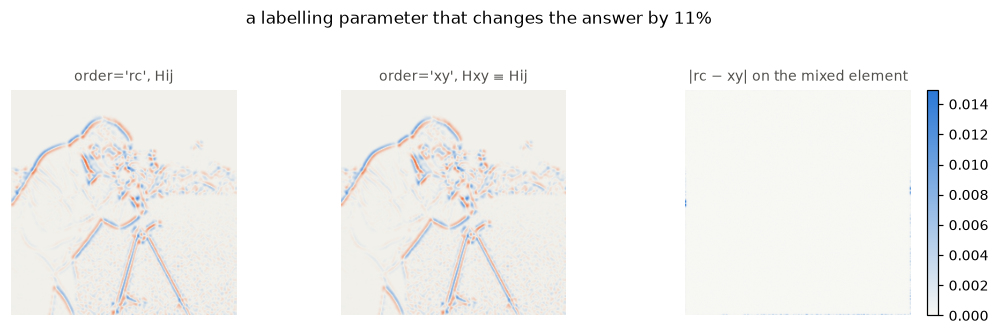

In [23]:
# The mixed element under both labellings: disagreement sits at the border.
fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.8))
show(axes[0], rc[1], "order='rc', Hij", diverging=True)
show(axes[1], xy[1], "order='xy', Hxy ≡ Hij", diverging=True)
im = show(axes[2], np.abs(rc[1] - xy[1]), "|rc − xy| on the mixed element")
fig.colorbar(im, ax=axes[2], fraction=0.046)
fig.suptitle("a labelling parameter that changes the answer by 11%", y=1.04)
fig.tight_layout()

Eleven per cent apart on this photograph, for a parameter documented as
choosing between two labellings of one answer. Neither is right: both are
approximations that disagree at the border, and the standard says so. The figure
depends on the image — on uniform random data it reaches 40% — because it is
driven by how much structure sits near the edge.

## 7. One pass, with corrected kernels

The border fault has an obvious remedy once the cause is named. Ask for the
whole derivative in **one** call per element, using the `order` vector to say
which axes to differentiate and how often — `[2, 0]`, `[1, 1]`, `[0, 2]`. Each
axis is then touched once, so the boundary rule is applied once, and the mixed
element has no first-or-second choice to get wrong.

That is route B again, and it brings back route B's problem: the even kernel
leaks at small `sigma`. So repair the kernel.

**What a discrete second derivative must do.** Two conditions, both statements
about the operator at zero frequency:

```
    sum(k)             ==  0        no response to a constant
    sum(k * x**2) / 2  ==  1        exact on f = x**2 / 2
```

Impose them after sampling. Subtract the leaked constant, then normalise the
second moment:

In [24]:
def corrected_taps(sigma, order, truncate=8):
    """Sampled Gaussian derivative with the discrete moments restored."""
    x, g = taps(sigma, 0, truncate)
    _, k = taps(sigma, order, truncate)
    if order == 0:
        return x, g
    if order == 1:
        return x, k / (k * x).sum()
    k = k - k.sum() * g                      # annihilate constants
    return x, k / ((k * x**2).sum() / 2)     # exact on quadratics


def one_pass(image, sigma, mode="nearest", truncate=8):
    """One call per element, with corrected kernels and no `truncate` guard."""
    kernels = {o: corrected_taps(sigma, o, truncate)[1] for o in (0, 1, 2)}
    sep = lambda a, b: ndi.correlate1d(
        ndi.correlate1d(image, kernels[a], axis=0, mode=mode),
        kernels[b], axis=1, mode=mode)
    return [sep(2, 0), sep(1, 1), sep(0, 2)]

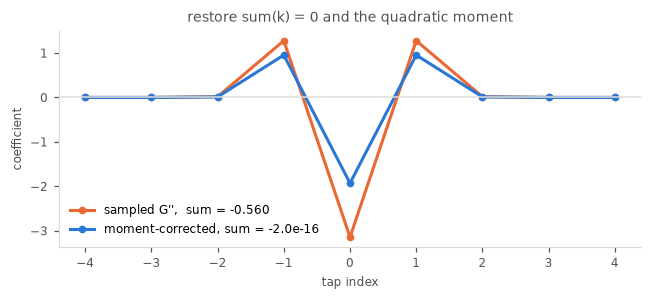

In [25]:
x_raw, k_raw = taps(0.5, 2, 8)
x_fix, k_fix = corrected_taps(0.5, 2, 8)
fig, ax = plt.subplots(figsize=(6.0, 2.8))
ax.plot(x_raw, k_raw, color=C_TWO, lw=2, marker="o", ms=4,
        label=f"sampled G'',  sum = {k_raw.sum():+.3f}")
ax.plot(x_fix, k_fix, color=C_ONE, lw=2, marker="o", ms=4,
        label=f"moment-corrected, sum = {k_fix.sum():+.1e}")
ax.axhline(0, color=GRID, lw=1)
ax.set_xlabel("tap index", fontsize=8, color=MUTED)
ax.set_ylabel("coefficient", fontsize=8, color=MUTED)
recede(ax, "restore sum(k) = 0 and the quadratic moment")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

This is not a new idea. [DIPlib](https://diplib.org) does exactly this, and its
author gave the recipe in the answer to the Stack Exchange question above —
`g2 -= np.mean(g2)` then `g2 /= np.sum(g2 * x**2) / 2.0`. VIGRA does the same in
`initGaussianDerivative`. ITK avoids the problem from the other side, building
Lindeberg's discrete analogue and convolving with a difference operator, which
sums to zero by construction. Only SciPy samples and leaves it, and only
`scikit-image` works around SciPy rather than correcting the kernel.

### Against the standard

In [26]:
rows = []
for sigma in (0.4, 0.5, 1.0, 1.5, 3.0):
    tw, ti = border_and_interior(two_pass, PHOTO, sigma)
    ow, oi = border_and_interior(one_pass, PHOTO, sigma)
    rows.append({
        "sigma": sigma,
        "two-pass, worst": f"{tw:.1%}",
        "two-pass, interior": f"{ti:.1%}",
        "one-pass, worst": f"{ow:.1%}",
        "one-pass, interior": f"{oi:.1%}",
    })
show_table(pd.DataFrame(rows))

|   sigma | two-pass, worst   | two-pass, interior   | one-pass, worst   | one-pass, interior   |
|--------:|:------------------|:---------------------|:------------------|:---------------------|
|     0.4 | 99.9%             | 99.9%                | 22.2%             | 20.5%                |
|     0.5 | 97.5%             | 97.5%                | 18.2%             | 18.2%                |
|     1   | 19.2%             | 10.3%                | 1.8%              | 1.8%                 |
|     1.5 | 18.9%             | 0.0%                 | 0.0%              | 0.0%                 |
|     3   | 19.2%             | 0.0%                 | 0.0%              | 0.0%                 |

From `sigma = 1.5` upwards the one-pass column is zero in both places: the
border band of about a fifth of the peak becomes floating-point noise, and the
interior stays exact. At `sigma = 1` the worst error falls from 19% to 1.8%, and
the interior error — the lost gain of section 5 — falls with it.

Below `sigma = 1` the one-pass scheme is far better than the two-pass one, 18%
against 98%, and is not *good*. Its remaining error is no longer at the border:
the worst and interior figures are now the same number, so what is left is the
aliasing residual, spread across the image. Correcting the moments does not
remove that, and the last part of this section says why.

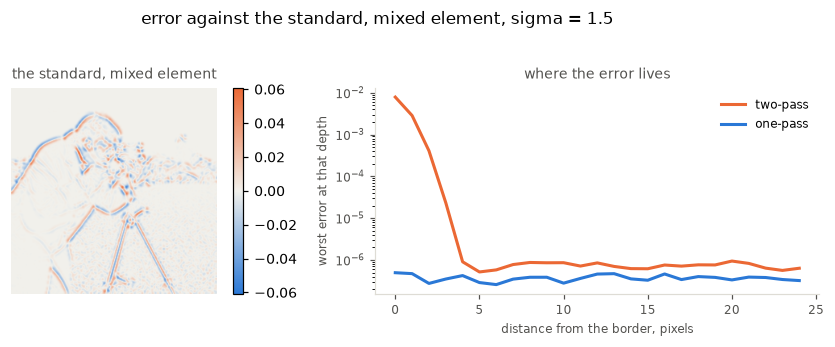

In [27]:
sigma = 1.5
truth = gold_hessian(PHOTO, sigma)
gap_two = np.abs(two_pass(PHOTO, sigma)[1] - truth[1])
gap_one = np.abs(one_pass(PHOTO, sigma)[1] - truth[1])

rows, cols = np.indices(PHOTO.shape)
to_edge = np.minimum(np.minimum(rows, cols),
                     np.minimum(PHOTO.shape[0] - 1 - rows,
                                PHOTO.shape[1] - 1 - cols))

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.0),
                         gridspec_kw={"width_ratios": [1, 1.4]})
image = show(axes[0], truth[1], "the standard, mixed element", diverging=True)
fig.colorbar(image, ax=axes[0], fraction=0.046)

for gap, name, colour in ((gap_two, "two-pass", C_TWO), (gap_one, "one-pass", C_ONE)):
    profile = [gap[to_edge == d].max() for d in range(25)]
    axes[1].semilogy(range(25), profile, color=colour, lw=2, label=name)
axes[1].set_xlabel("distance from the border, pixels", fontsize=8, color=MUTED)
axes[1].set_ylabel("worst error at that depth", fontsize=8, color=MUTED)
recede(axes[1], "where the error lives")
axes[1].legend(frameon=False, fontsize=8)
fig.suptitle(f"error against the standard, mixed element, sigma = {sigma}", y=1.03)
fig.tight_layout()

The profile is the whole of it. The two-pass error starts four orders of
magnitude above the one-pass error at the outermost pixel and falls to meet it
about five pixels in; from there the two curves lie together. So the two-pass
scheme is not worse everywhere, it is worse in a band — and the band is where
the second call's invented boundary values reach.

The floor both curves settle on, around `5e-7`, is not zero. It is this
notebook's standard disagreeing with both methods by the residual of its own
construction, which is the honest limit of what can be claimed here: below that
level, the reference cannot referee.

The `order` inconsistency goes with it, not by being reduced but by ceasing to
exist: `[2, 0]` and `[0, 2]` are each other's mirror and `[1, 1]` is its own, so
relabelling the axes permutes the three results and changes nothing else.

In [28]:
def one_pass_xy(image, sigma):
    return one_pass(image, sigma)[::-1]


scale = max(np.abs(e).max() for e in one_pass(PHOTO, 1.5))
gap = max(np.abs(a - b).max()
          for a, b in zip(one_pass(PHOTO, 1.5), one_pass_xy(PHOTO, 1.5)[::-1])) / scale
print(f"one-pass, order='rc' against order='xy': {gap:.1e} of the peak")

one-pass, order='rc' against order='xy': 0.0e+00 of the peak


And `truncate = 100` can go, which is what pays for the change.

In [29]:
import time


def best_of(f, n=5):
    f()
    return min([(lambda t0: (f(), time.perf_counter() - t0)[1])(time.perf_counter())
                for _ in range(n)])


rows = []
for sigma in (0.5, 1.0, 1.5, 3.0):
    t_two = best_of(lambda: two_pass(PHOTO, sigma))
    t_one = best_of(lambda: one_pass(PHOTO, sigma))
    rows.append({
        "sigma": sigma,
        "two-pass (ms)": t_two * 1e3,
        "one-pass (ms)": t_one * 1e3,
        "ratio": t_one / t_two,
    })
show_table(pd.DataFrame(rows), floatfmt=".2f")

|   sigma |   two-pass (ms) |   one-pass (ms) |   ratio |
|--------:|----------------:|----------------:|--------:|
|    0.50 |           23.21 |            3.56 |    0.15 |
|    1.00 |           77.83 |            4.21 |    0.05 |
|    1.50 |            7.16 |            5.20 |    0.73 |
|    3.00 |           12.22 |           10.73 |    0.88 |

Faster as well as more accurate, and dramatically so below `sigma = 1`, because
the guard that made the kernel a hundred taps wide is no longer needed.

**What this does not fix.** Correcting the moments does not undo the aliasing.
Sampling folds everything above the Nyquist frequency back into the band, and no
choice of coefficients unfolds it. What the two conditions do is pin the
operator to the ideal at zero frequency, which removes the two errors that are
wrong for *every* image — a response to constants, and the wrong gain on smooth
features. A residual remains at high frequency and grows toward Nyquist. It
matters least where the method is used, because smoothing at scale `sigma` is
precisely what removes the content the residual would affect.

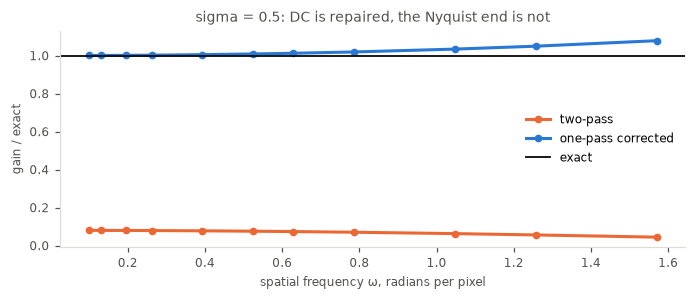

In [30]:
# Gain on a pure sinusoid row: moment repair fixes DC, not the approach to Nyquist.
def sine_gain(method, sigma, waves):
    """Peak response / exact (−ω² e^{−σ²ω²/2}) for f = cos(ω j), ω = 2π / waves."""
    width = 512
    j = np.arange(width, dtype=float)
    gains = []
    for period in waves:
        omega = 2 * np.pi / period
        row = np.cos(omega * j)
        image = np.repeat(row[None, :], 64, axis=0)
        got = method(image, sigma)[2]          # Hjj: second deriv along columns
        # Exact continuous answer after Gaussian smoothing of scale sigma:
        # ∂²/∂x² (Gσ * cos(ωx)) = −ω² exp(−σ² ω² / 2) cos(ωx).
        exact_amp = (omega ** 2) * np.exp(-(sigma ** 2) * (omega ** 2) / 2)
        # Exclude a border margin so edge extension does not inflate the peak.
        gains.append(np.abs(got[32, 40:-40]).max() / exact_amp)
    return np.asarray(gains)


periods = np.array([4, 5, 6, 8, 10, 12, 16, 24, 32, 48, 64])
fig, ax = plt.subplots(figsize=(6.4, 2.8))
for method, name, colour in (
        (two_pass, "two-pass", C_TWO),
        (one_pass, "one-pass corrected", C_ONE),
):
    ax.plot(2 * np.pi / periods, sine_gain(method, 0.5, periods),
            color=colour, lw=2, marker="o", ms=4, label=name)
ax.axhline(1.0, color=INK, lw=1.2, label="exact")
ax.set_xlabel("spatial frequency ω, radians per pixel", fontsize=8, color=MUTED)
ax.set_ylabel("gain / exact", fontsize=8, color=MUTED)
recede(ax, "sigma = 0.5: DC is repaired, the Nyquist end is not")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## 8. What `mode` does, and to which method

`mode` says how to continue the image past its edge. It is a statement about
what is *outside*, so it cannot touch the interior: any method whose interior
moves when `mode` changes has a defect that has nothing to do with boundaries.
That makes it a useful probe, and the three methods answer it differently.

The standard has to be computed in the matching mode, or the comparison
measures the mismatch. It is stable enough to referee in all five.

In [31]:
MODES = ("nearest", "reflect", "mirror", "wrap", "constant")

rows = []
for mode in MODES:
    coarse = gold_hessian(PHOTO, 1.5, factor=4, mode=mode)
    finer = gold_hessian(PHOTO, 1.5, factor=8, mode=mode)
    scale = max(np.abs(e).max() for e in finer)
    gap = max(np.abs(a - b).max() for a, b in zip(coarse, finer)) / scale
    rows.append({"mode": mode, "k=4 vs k=8": f"{gap:.1e}"})
show_table(pd.DataFrame(rows))

| mode     |   k=4 vs k=8 |
|:---------|-------------:|
| nearest  |      5.6e-14 |
| reflect  |      5.6e-14 |
| mirror   |      5.7e-14 |
| wrap     |      5.6e-14 |
| constant |      5.7e-14 |

In [32]:
def mode_error(method, sigma, mode, margin=20):
    truth = gold_hessian(PHOTO, sigma, mode=mode)
    got = method(PHOTO, sigma, mode=mode)
    scale = max(np.abs(e).max() for e in truth)
    inner = (slice(margin, -margin),) * 2
    return (max(np.abs(a - b).max() for a, b in zip(got, truth)) / scale,
            max(np.abs(a[inner] - b[inner]).max() for a, b in zip(got, truth)) / scale)


print("sigma = 1.5, worst error anywhere / interior only")
rows = []
for mode in MODES:
    row = {"mode": mode}
    for label, method in (("route A", route_a), ("two-pass", two_pass),
                          ("one-pass", one_pass)):
        whole, inner = mode_error(method, 1.5, mode)
        row[f"{label}, worst"] = f"{whole:.1%}"
        row[f"{label}, interior"] = f"{inner:.1%}"
    rows.append(row)
show_table(pd.DataFrame(rows))

sigma = 1.5, worst error anywhere / interior only


| mode     | route A, worst   | route A, interior   | two-pass, worst   | two-pass, interior   | one-pass, worst   | one-pass, interior   |
|:---------|:-----------------|:--------------------|:------------------|:---------------------|:------------------|:---------------------|
| nearest  | 27.8%            | 27.8%               | 18.9%             | 0.0%                 | 0.0%              | 0.0%                 |
| reflect  | 43.6%            | 27.8%               | 45.0%             | 0.0%                 | 0.0%              | 0.0%                 |
| mirror   | 41.4%            | 27.8%               | 60.5%             | 0.0%                 | 0.0%              | 0.0%                 |
| wrap     | 27.8%            | 27.8%               | 0.0%              | 0.0%                 | 0.0%              | 0.0%                 |
| constant | 31.9%            | 27.8%               | 58.9%             | 0.0%                 | 0.0%              | 0.0%                 |

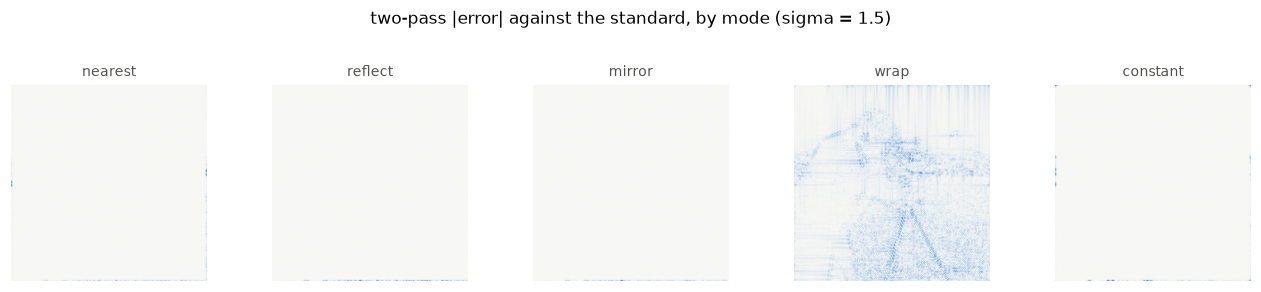

In [33]:
# Border error of the mixed element, two-pass, by mode — same diagnosis drawn.
sigma = 1.5
fig, axes = plt.subplots(1, 5, figsize=(12.0, 2.4))
for ax, mode in zip(axes, MODES):
    truth = gold_hessian(PHOTO, sigma, mode=mode)
    gap = np.abs(two_pass(PHOTO, sigma, mode=mode)[1] - truth[1])
    show(ax, gap, mode)
fig.suptitle("two-pass |error| against the standard, by mode (sigma = 1.5)",
             y=1.08)
fig.tight_layout()

**Route A ignores `mode` where it matters.** Its interior error is 27.8%
whatever `mode` says, which is right — `mode` should not reach the interior. But
its *border* error changes with `mode` for a reason that is not to the caller's
credit: `np.gradient` applies one-sided differences at the first and last row
and column, and no `mode` controls that. The smoothing honours the caller's
choice; the differencing then imposes an edge rule of its own on top.

In [34]:
# A quadratic separates the two stencils: the central difference is exact on
# it, a one-sided difference is not.
ramp = np.arange(7.0) ** 2
show_table(pd.DataFrame({
    "x": np.arange(7),
    "exact 2x": 2 * np.arange(7.0),
    "np.gradient": np.gradient(ramp),
}))
print("interior uses (f[n+1] - f[n-1]) / 2 and is exact here;")
print("the two ends fall back to a one-sided difference and are not.")
print("No value of `mode` reaches that choice — it is made inside np.gradient.")

|   x |   exact 2x |   np.gradient |
|----:|-----------:|--------------:|
|   0 |          0 |             1 |
|   1 |          2 |             2 |
|   2 |          4 |             4 |
|   3 |          6 |             6 |
|   4 |          8 |             8 |
|   5 |         10 |            10 |
|   6 |         12 |            11 |

interior uses (f[n+1] - f[n-1]) / 2 and is exact here;
the two ends fall back to a one-sided difference and are not.
No value of `mode` reaches that choice — it is made inside np.gradient.


`nearest` and `wrap` come off best for route A, at 27.8% — no worse at the
border than in the interior — because an edge-replicated or wrapped image is
locally smooth across the seam, so a one-sided difference happens to be close.
`reflect` and `mirror` are worst, at 43.6% and 41.4%: reflection makes the true
derivative zero at the edge by symmetry, and a one-sided estimate does not know
that.

That 27.8% interior figure is worth a note of its own, because section 4 put
route A at about 5% on the blob. Both are right. The floor is
`sin(w)**2 / w**2`, which depends on what frequencies the image contains, and a
photograph contains far more high-frequency content than a smooth Gaussian blob.

In [35]:
rows = []
for name, image in (("blob", blob), ("camera", PHOTO)):
    truth = gold_hessian(image, 1.5, mode="nearest")
    got = route_a(image, 1.5, mode="nearest")
    scale = max(np.abs(e).max() for e in truth)
    inner = (slice(35, -35),) * 2
    err = max(np.abs(a[inner] - b[inner]).max()
              for a, b in zip(got, truth)) / scale
    rows.append({"image": name, "route A, interior": f"{err:.1%}"})
show_table(pd.DataFrame(rows))

| image   | route A, interior   |
|:--------|:--------------------|
| blob    | 5.3%                |
| camera  | 27.8%               |

**The two-pass scheme is exact under `wrap`, and only under `wrap`.** Its
interior is exact in every mode, as it should be. Its border error runs from
about 19% to 60% — and falls to the interior floor (a few parts in ten
thousand, printing as zero at one decimal) for periodic boundaries.

That is the diagnosis of section 6 confirmed from the other side. The scheme
fails because the second call re-extends an array the first has already
smoothed, and the rule it applies is the rule for an image, not for a derivative
field. Under `wrap` there is no such thing as outside: a periodic signal's
continuation is exact, it is the same for the image and for every field derived
from it, and applying it twice is applying it once. Remove the guesswork and the
border defect goes with it.

The ranking of the other four follows the same logic. `nearest` is the least bad
at 18.9%, because a replicated edge is at least a plausible continuation of a
smoothed field. `reflect`, `mirror` and `constant` are all worse, at 45%, 61%
and 59%, because each asserts something specific about the derivative field
outside that is not true of it.

**The one-pass scheme does not care.** Zero in every mode, because each axis is
extended once and a boundary extension along one axis commutes exactly with
filtering along another. There is no second extension to be wrong.

### What to take from it

Do not choose a `mode` to dodge this. `wrap` makes the two-pass border error
vanish into the interior floor, and almost no image is periodic: choosing it
would replace a border artefact with a different and larger one, of the left
edge bleeding into the right. The right reading is diagnostic — the fact that
one mode removes the border error entirely is the strongest evidence that the
defect is the extension and not the arithmetic.

For a caller today, `mode='nearest'` is the least damaging choice with the
shipped scheme, at a third of the error of `mirror`. That is a workaround, and
it costs nothing to say so. After the one-pass change the choice goes back to
being what the documentation says it is: a statement about what lies outside the
image, with no effect on the answer inside it.

## 9. What changes for the callers

`hessian_matrix` is not used directly by most of the people who depend on it. It
is consumed by four ridge filters, and the question that decides whether this is
worth doing is what happens to them.

The same standard applies. A ridge filter run on a once-extended image and
cropped back is the answer it *should* give: the interior pixels have seen no
edge, so nothing in the result is a border artefact. Comparing each filter
against that says how much of its output is real.

In [36]:
import importlib
import sys
from unittest import mock

PAD = 110                                   # clears truncate = 100 at sigma = 1
RIDGE = dict(mode="nearest")                # matches np.pad(..., mode='edge')
padded_photo = np.pad(PHOTO, PAD, mode="edge")
FILTERS = [("frangi", frangi), ("sato", sato),
           ("meijering", meijering), ("hessian", hessian)]

package = sys.modules[frangi.__module__].__package__.rsplit(".", 1)[0]
corner_mod = importlib.import_module(f"{package}.feature.corner")


def as_hessian_matrix(rule):
    """Wrap a Hessian rule in the `hessian_matrix` signature, ready to patch in."""
    def replacement(image, sigma=1, mode="reflect", cval=0, order="rc",
                    use_gaussian_derivatives=True):
        return rule(ski.util.img_as_float(image), sigma, mode=mode)
    return replacement


def ridge_border_frame():
    rows = []
    for name, f in FILTERS:
        direct = f(PHOTO, **RIDGE)
        reference = f(padded_photo, **RIDGE)[PAD:-PAD, PAD:-PAD]
        gap = np.abs(direct - reference)
        rows.append({
            "filter": name,
            "worst vs pad-once": f"{gap.max() / max(np.abs(reference).max(), 1e-12):.1%}",
            "30 px in": f"{gap[30:-30, 30:-30].max():.1e}",
        })
    return pd.DataFrame(rows)


display(Markdown("**as shipped, two-pass**"))
show_table(ridge_border_frame())
with mock.patch.object(corner_mod, "hessian_matrix", as_hessian_matrix(one_pass)):
    display(Markdown("**with one-pass corrected kernels**"))
    show_table(ridge_border_frame())

**as shipped, two-pass**

| filter    | worst vs pad-once   |   30 px in |
|:----------|:--------------------|-----------:|
| frangi    | 9.9%                |    4.5e-11 |
| sato      | 9.3%                |    1.5e-07 |
| meijering | 26.3%               |    0.033   |
| hessian   | 100.0%              |    6.8e-15 |

**with one-pass corrected kernels**

| filter    | worst vs pad-once   |   30 px in |
|:----------|:--------------------|-----------:|
| frangi    | 0.0%                |      0     |
| sato      | 0.0%                |      0     |
| meijering | 3.3%                |      0.033 |
| hessian   | 0.0%                |      0     |

Three of the four become exact — not improved, exact. `meijering` does not, and
the residue is its *interior* figure, unchanged: it divides each scale by that
scale's maximum over the whole image, so its output at a pixel depends on pixels
arbitrarily far away, and a once-extended image is a larger image with a
different maximum. That is a separate defect, in `meijering` alone, which the
border fix exposes rather than causes. `on_meijering.md` is about it.

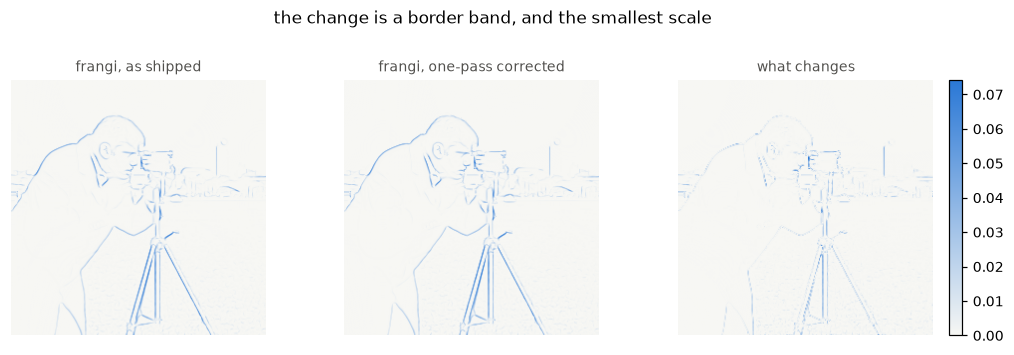

In [37]:
sigma_sweep = dict(sigmas=(1, 3, 5), mode="nearest")
before = frangi(PHOTO, **sigma_sweep)
with mock.patch.object(corner_mod, "hessian_matrix", as_hessian_matrix(one_pass)):
    after = frangi(PHOTO, **sigma_sweep)

fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.0))
show(axes[0], before, "frangi, as shipped")
show(axes[1], after, "frangi, one-pass corrected")
image = show(axes[2], np.abs(before - after), "what changes")
fig.colorbar(image, ax=axes[2], fraction=0.046)
fig.suptitle("the change is a border band, and the smallest scale", y=1.03)
fig.tight_layout()

### Why the new numbers are the better ones

Output changes, so the question is not "are they different" but "is the
difference an improvement". Three things answer it, and none of them is a
preference.

**At the border, the old values are wrong against a standard fixed in advance.**
Not different from the new ones — wrong, by about a fifth of the peak response,
against a reference that applies the documented boundary rule once and is agreed
before either method is run.

**In the interior below `sigma = 1`, the old values lose gain.** Section 5
measured the two-pass scheme reporting 8% of the curvature of a quadratic at
`sigma = 0.5`. The corrected kernel reports it exactly. A filter sweeping small
scales was reading real structure as nearly flat.

**The `order` argument stops meaning two things.** Today `order='rc'` and
`order='xy'` differ by 11% on this photograph, and by 40% on less forgiving
data, for a quantity documented as one tensor in two labellings. After the
change they are the same numbers permuted, which is what the docstring already
claims.

In [38]:
show_table(pd.DataFrame([
    {"check": "border error, sigma >= 1.5",
     "two-pass": "~19% of the peak", "one-pass corrected": "floating-point noise"},
    {"check": "interior, sigma >= 1.5",
     "two-pass": "exact", "one-pass corrected": "exact"},
    {"check": "quadratic gain at sigma = 0.5",
     "two-pass": "0.08", "one-pass corrected": "1.00"},
    {"check": "response to a constant",
     "two-pass": "0", "one-pass corrected": "~1e-17"},
    {"check": "order='rc' vs 'xy'",
     "two-pass": "~11% apart", "one-pass corrected": "identical"},
    {"check": "cost at sigma = 1",
     "two-pass": "1x", "one-pass corrected": "about 0.05x"},
]))

| check                         | two-pass         | one-pass corrected   |
|:------------------------------|:-----------------|:---------------------|
| border error, sigma >= 1.5    | ~19% of the peak | floating-point noise |
| interior, sigma >= 1.5        | exact            | exact                |
| quadratic gain at sigma = 0.5 | 0.08             | 1.00                 |
| response to a constant        | 0                | ~1e-17               |
| order='rc' vs 'xy'            | ~11% apart       | identical            |
| cost at sigma = 1             | 1x               | about 0.05x          |

The one place the old scheme is better is a test it was designed against: on a
perfectly constant image it returns exactly zero, where the corrected kernel
returns `1e-17`. That is the difference between a symmetry and a numerical
correction, and it is not a reason to prefer it.

### What is still open

The corrected kernel is not the last word. It fixes the operator at zero
frequency and leaves a residual that grows toward Nyquist, so at `sigma` well
below 1 no kernel repair rescues the method — only a larger scale, or a finer
grid, does. `hessian_matrix_det(approximate=True)` and `blob_doh` route through
box filters over integral images and are untouched by any of this; they have
their own border defect, larger than this one, described in `on_blob_dog.md`.
And `meijering`'s normalisation needs deciding on its own terms.

Measured with scikit-image from this working tree, on a 121x121 analytic blob
and the 256x256 `camera` photograph, against a supersampled reference at
refinement factor 4.

In [39]:
print(f"scikit-image {ski.__version__}")
print(f"scipy        {__import__('scipy').__version__}")

scikit-image 0.26.1rc0.dev0+git20260909.b6e9c5ce5
scipy        1.18.1
